# AdventureWorks Customer Segmentation
## RFM-Based K-Means Clustering - Internet Customer Analysis
 
**Dataset:** Microsoft AdventureWorks Sample Data  
**Tools:** Python, scikit-learn, pandas, matplotlib  
**Date:** 2025


## Executive Summary

**Key context before reading:**

Unlike the reseller network where 53% of accounts are unprofitable, the Internet channel tells a completely different story - **all 18,484 customers are profitable** with an average margin of ~40-58%. The challenge here is not profitability but engagement - understanding which customers are loyal high-value accounts vs which are at risk of lapsing permanently.

**Three segment output (actual results):**

| Segment | Count | Avg Revenue | Avg Orders | Avg Recency | Avg Margin | Priority |
|---|---|---|---|---|---|---|
| Champions | 8,769 (47%) | \$3,126 | 4.0 | 160 days | 40% | Protect and reward |
| Occasional Buyers | 9,209 (50%) | \$61 | 2.7 | 157 days | 58% | Develop and grow |
| High Value At Risk | 506 (3%) | \$2,727 | 1.0 | 759 days | 41% | Urgent re-engagement |

**Three findings that shaped the recommendations:**

1. **Champions are the majority** - 47% of customers fall into the highest value segment, indicating the Internet channel has a healthy engaged base. The commercial opportunity is developing Occasional Buyers rather than rescuing a small loyal base.

2. **Occasional Buyers have very low average revenue (\$61)** - these are low-value transactional customers who bought once or twice at low price points. Their high margin (58%) reflects the product mix - likely Accessories and Clothing rather than Bikes. The opportunity is frequency improvement not basket size.

3. **High Value At Risk is small but commercially urgent** - only 506 customers but averaging \$2,727 revenue each with over 2 years since last purchase. These are high-value customers who have gone quiet. With \$1.38M total revenue at stake this group should be the first priority for re-engagement investment.

> *For business recommendations scroll to Section 11. For technical methodology start at Section 3.*


## Recommendations

---

### 1. Re-engage High Value At Risk through accessories and components - not replacement bikes
506 customers averaging $2,727 lifetime revenue have not purchased in over 2 years. Given that quality bikes are durable goods with 5-10 year replacement cycles this recency gap does not necessarily indicate churn, these customers likely still own and ride their AdventureWorks bike and simply have no need for a replacement yet.

The real opportunity is cross-sell into adjacent repeat-purchase categories:
- **Accessories** - helmets, gloves, cycling computers, lights
- **Clothing** - jerseys, shorts, base layers, rain gear
- **Components** - tyres, brake pads, chains (wear items with 1-2 year replacement cycles)

A customer who spent $2,727 on a bike is the ideal target for accessories marketing as they are invested in the product and have demonstrated willingness to spend. Their lifetime value has significant upside through category expansion without needing a replacement bike purchase.

**Suggested action:** Segment these 506 customers by their original purchase category. Those who bought Bikes should receive accessories and components campaigns timed around typical wear cycles such as tyres and chains at 12-18 months, apparel annually. Do not lead with replacement bike messaging as the timing is almost certainly wrong and it signals the business does not understand the customer purchase cycle.

---

### 2. Protect Champions - do not disrupt what is working
8,769 customers (47% of the base) are actively purchasing at $3,126 average revenue and 4 orders per customer. This is a healthier loyal base than most retail businesses achieve. The risk is disrupting it such as an aggressive promotional pricing or product availability issues could push Champions toward lapse.

**Suggested action:** Establish a Champions tier with visible benefits - early product access, priority customer service, loyalty recognition. The goal is making Champions feel valued enough to stay rather than actively trying to increase their spend. Revenue protection is more valuable than marginal upsell here.

---

### 3. Develop Occasional Buyers through frequency programmes
9,209 customers (50% of the base) averaging just $61 revenue and 2.7 orders. These customers are not disengaged as their recency (157 days) is similar to Champions (160 days). They simply purchase at lower value and less frequently.

Two distinct sub-groups likely exist within Occasional Buyers:
- Accessory and Clothing buyers - low average order value, high margin, potential to cross-sell into Bikes
- Infrequent Bike buyers - moderate order value but very low frequency

**Suggested action:** Run a cross-sell campaign targeting Occasional Buyers who have purchased Accessories or Clothing but never a Bike. A first Bike purchase would dramatically increase their lifetime value and likely move them into Champions territory.

---

### 4. Build a frequency-based loyalty programme
The median customer orders only 3 times across the full four year period which is less than once per year. Champions average 4 orders which is better but still low for a loyal customer base. There is significant headroom to increase purchase frequency particularly through accessories and components which have natural repurchase cycles.

**Suggested action:** Design a tiered loyalty programme - points per order, with Champions tier unlocked at 5+ lifetime orders. Even moving the median from 3 to 4 orders per customer would generate a material revenue uplift across 18,000 customers.

---

### 5. Use purchase category to personalise all re-engagement campaigns
The bike replacement cycle is 5-10 years for a quality product - meaning recency alone is not a reliable churn signal for this business. A customer who bought a bike 2 years ago is not necessarily lapsed, they simply do not need another bike yet.

This has implications across all segments:
- **Champions** who purchased Bikes should receive accessories and components campaigns between bike purchases to maintain engagement
- **Occasional Buyers** who purchased only Accessories or Clothing have a much shorter natural repurchase cycle and are the right target for frequency programmes
- **High Value At Risk** customers should never receive replacement bike campaigns - Accessories, Clothing, and Components are the right category focus

**Suggested action:** Add purchase category as a dimension to all customer communications. Customers who have purchased a Bike in the last 3 years should receive accessories-led messaging. Customers whose last purchase was Accessories or Clothing should receive frequency-based repurchase prompts. This simple segmentation layer would significantly improve campaign relevance and response rates.

---

### 6. Track segment migration quarterly
A Champion who stops ordering for 6 months is drifting toward High Value At Risk. Without quarterly re-segmentation that drift is invisible until the customer is already lapsed.

**Suggested action:** Re-run this segmentation quarterly and build a Power BI migration matrix showing how customers move between segments. Champions moving to Occasional Buyers or High Value At Risk is an early warning signal requiring immediate outreach before the relationship is lost.

---


## 1. Introduction and Business Problem

The AdventureWorks Internet channel serves 18,484 customers across six countries - United States, Australia, United Kingdom, France, Germany, and Canada they purchase directly through the online channel between July 2017 and June 2020.

The dashboard analysis showed the Internet channel operating at ~41% profit margin which is dramatically higher than the Reseller channel's ~0.6%. The commercial question for this analysis is not profitability but engagement:

> *Which customers are loyal high-value accounts, which are occasional low-value buyers, and which high-value customers are at risk of never returning?*

Answering this question enables the business to allocate marketing and customer service resources more effectively - protecting the customers who matter most while re-engaging those drifting toward churn.

### Why RFM for customer segmentation?

RFM - Recency, Frequency, Monetary - is the industry standard framework for customer segmentation in retail and ecommerce contexts. It captures three dimensions that together describe the health of a customer relationship:

- **Recency** - how recently did they last purchase? Recent purchasers are more likely to buy again
- **Frequency** - how often do they buy? High frequency indicates loyalty and habit
- **Monetary** - how much do they spend? High monetary value identifies the most commercially important accounts

RFM is deliberately interpretable resulting in a sales or marketing team understanding and acting on these dimensions without needing to understand the clustering algorithm. This makes it more commercially useful than more complex feature sets.

### Key difference from reseller segmentation

The reseller analysis required a two-stage approach because 53% of resellers were unprofitable - profitability had to be the primary segmentation dimension.

Customer segmentation is simpler as all 18,484 Internet customers are profitable (avg 40-58% margin depending on segment). The clustering focuses purely on engagement behaviour - recency, frequency, and monetary value.

### What the data actually showed

The results were not what might be intuitively expected:

- **Champions are the majority** - 47% of customers fall into the highest engagement segment. The Internet channel has a healthier loyal base than the thin blended average margin might suggest.
- **Occasional Buyers dominate by count** - 50% of customers are low-value transactional buyers. But their recency is similar to Champions - they are not lapsing, they are simply low-spend.
- **High Value At Risk is tiny but urgent** - only 506 customers but averaging $2,727 each with over 2 years since last purchase. These are the commercial priority despite being a small group.


## 2. Setup and Configuration

In [3]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

# ── Configuration ──
FILE_PATH = "AdventureWorks_Sales_Cleaned.xlsx"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
MAX_K = 8

# Colour palette - matches Power BI dashboard theme
SEGMENT_COLOURS = {
    "Champions": "#1F4E79",
    "Occasional Buyers": "#2563eb",
    "High Value At Risk": "#E63946",
}

COLOUR_ACTUAL = "#1F4E79"
COLOUR_HIGHLIGHT = "#E63946"

print("Setup complete")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Setup complete
Output directory: C:\Users\he145100\outputs


## 3. Data Loading

Three sheets are required - Sales transactions, Sales Order channel identifiers, and Customer metadata for geographic enrichment.


In [4]:
def load_data(file_path: str) -> dict[str, pd.DataFrame]:
    """
    Loads sheets required for customer segmentation.

    Parameters
    ----------
    file_path : str
        Path to cleaned AdventureWorks workbook

    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary of dataframes keyed by short name
    """
    sheets = {
        "sales": "Sales",
        "customer": "Customer",
        "sales_order": "Sales Order",
        "product": "Product",
    }
    data = {}
    for key, sheet_name in sheets.items():
        data[key] = pd.read_excel(file_path, sheet_name=sheet_name)
        print(f"  Loaded {sheet_name:<25} {len(data[key]):>7,} rows")
    return data

print("Loading data...")
data = load_data(FILE_PATH)
print("\nAll sheets loaded")


Loading data...
  Loaded Sales                     121,253 rows
  Loaded Customer                   18,484 rows
  Loaded Sales Order               121,253 rows
  Loaded Product                       397 rows

All sheets loaded


## 4. Feature Engineering - Building the RFM Table

Each customer is described by five features derived from their transaction history. The standard RFM dimensions are extended with Average Order Value and Product Category breadth to give a richer picture of purchasing behaviour.


In [5]:
def build_rfm_features(data: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Constructs a customer-level RFM feature table.

    Features engineered per customer:
    - Recency - days since last purchase (lower = more recent = better)
    - Frequency - total number of order lines
    - Monetary - total lifetime revenue
    - Avg_Order_Value - revenue divided by order count
    - Unique_Categories - product category breadth
    - Profit_Margin_Pct - lifetime margin percentage
    - Tenure_Days - days between first and last order

    Parameters
    ----------
    data : dict[str, pd.DataFrame]
        Raw dataframes from load_data()

    Returns
    -------
    pd.DataFrame
        One row per customer with engineered RFM features
    """
    sales = data["sales"].copy()
    sales_order = data["sales_order"].copy()
    product = data["product"].copy()

    # Filter to internet channel - exclude -1 surrogate key
    sales = sales[sales["CustomerKey"] != -1].copy()
    sales = sales.merge(
        sales_order[["SalesOrderLineKey", "Channel"]],
        on="SalesOrderLineKey", how="left"
    )
    sales = sales[sales["Channel"] == "Internet"].copy()
    sales = sales.merge(
        product[["ProductKey", "Category"]],
        on="ProductKey", how="left"
    )

    sales["Profit"] = sales["Sales Amount"] - sales["Total Product Cost"]
    sales["OrderDate"] = pd.to_datetime(
        sales["OrderDateKey"].astype(str), format="%Y%m%d"
    )

    # Reference date for recency calculation
    reference_date = sales["OrderDate"].max()
    logger.info(f"Reference date for recency: {reference_date.date()}")

    # Aggregate to customer level
    rfm = sales.groupby("CustomerKey").agg(
        Recency=("OrderDate", lambda x: (reference_date - x.max()).days),
        Frequency=("SalesOrderLineKey", "count"),
        Monetary=("Sales Amount", "sum"),
        Profit=("Profit", "sum"),
        Unique_Categories=("Category", "nunique"),
        Last_Order=("OrderDate", "max"),
        First_Order=("OrderDate", "min"),
    ).reset_index()

    rfm["Avg_Order_Value"] = (rfm["Monetary"] / rfm["Frequency"]).round(2)
    rfm["Profit_Margin_Pct"] = (rfm["Profit"] / rfm["Monetary"]).round(4)
    rfm["Tenure_Days"] = (rfm["Last_Order"] - rfm["First_Order"]).dt.days

    # Merge customer metadata
    customer_meta = data["customer"][
        ["CustomerKey", "Customer", "City", "State-Province", "Country-Region"]
    ]
    rfm = rfm.merge(customer_meta, on="CustomerKey", how="left")

    return rfm

rfm = build_rfm_features(data)

print(f"RFM table built - {len(rfm):,} customers")
print(f"\nRFM feature summary:")
print(rfm[["Recency", "Frequency", "Monetary",
           "Avg_Order_Value", "Profit_Margin_Pct"]].describe().round(2))


2026-04-07 08:31:54 - INFO - Reference date for recency: 2020-06-15


RFM table built - 18,484 customers

RFM feature summary:
        Recency  Frequency  Monetary  Avg_Order_Value  Profit_Margin_Pct
count  18484.00   18484.00  18484.00         18484.00           18484.00
mean     174.67       3.27   1588.33           507.10               0.49
std      145.64       2.62   2124.23           707.60               0.11
min        0.00       1.00      2.29             2.29               0.23
25%       71.00       2.00     49.97            19.99               0.39
50%      153.00       3.00    270.26            69.99               0.45
75%      248.00       4.00   2511.28           829.32               0.63
max     1080.00      68.00  13295.38          3578.27               0.63


## 5. Exploratory Analysis - Understanding the Customer Base

Before clustering it is important to understand the shape of the data. Three distributions are particularly important for RFM analysis - recency, frequency, and monetary value.


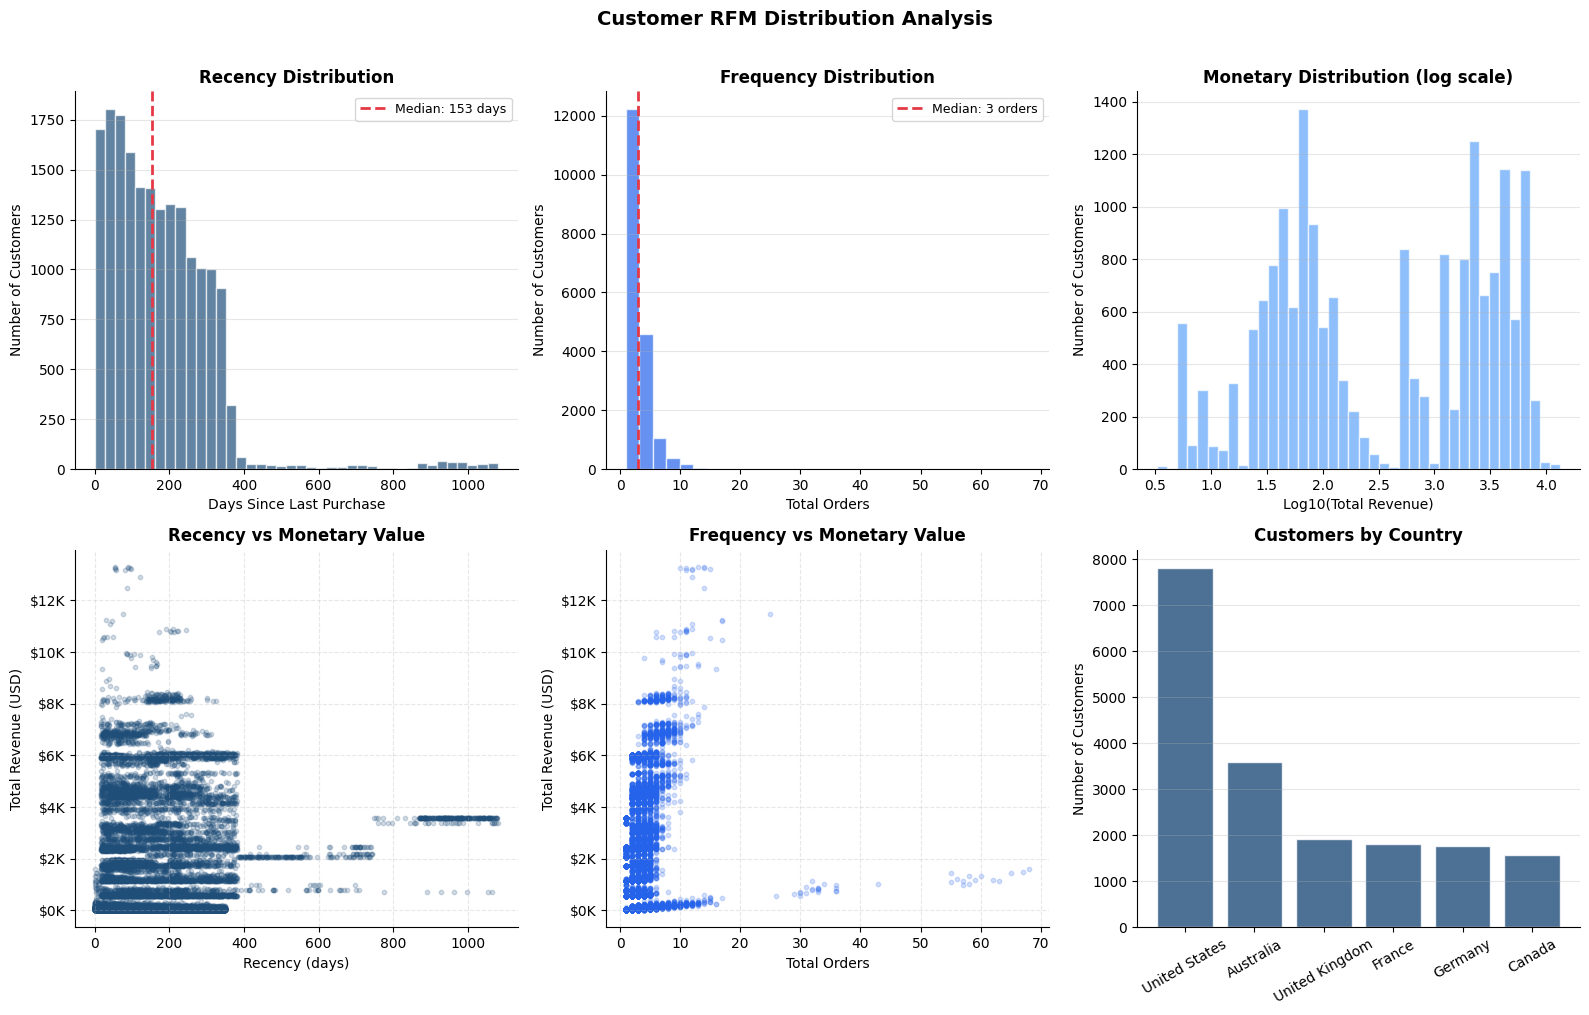

RFM distribution charts saved


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Customer RFM Distribution Analysis", fontsize=14,
             fontweight="bold", y=1.01)

# Recency distribution
axes[0, 0].hist(rfm["Recency"], bins=40, color=COLOUR_ACTUAL,
                alpha=0.7, edgecolor="white")
axes[0, 0].axvline(x=rfm["Recency"].median(), color=COLOUR_HIGHLIGHT,
                   linestyle="--", linewidth=2,
                   label=f"Median: {rfm['Recency'].median():.0f} days")
axes[0, 0].set_title("Recency Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Days Since Last Purchase")
axes[0, 0].set_ylabel("Number of Customers")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(axis="y", alpha=0.3)
axes[0, 0].spines["top"].set_visible(False)
axes[0, 0].spines["right"].set_visible(False)

# Frequency distribution
axes[0, 1].hist(rfm["Frequency"], bins=30, color="#2563eb",
                alpha=0.7, edgecolor="white")
axes[0, 1].axvline(x=rfm["Frequency"].median(), color=COLOUR_HIGHLIGHT,
                   linestyle="--", linewidth=2,
                   label=f"Median: {rfm['Frequency'].median():.0f} orders")
axes[0, 1].set_title("Frequency Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Total Orders")
axes[0, 1].set_ylabel("Number of Customers")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(axis="y", alpha=0.3)
axes[0, 1].spines["top"].set_visible(False)
axes[0, 1].spines["right"].set_visible(False)

# Monetary distribution - log scale due to heavy right skew
axes[0, 2].hist(np.log10(rfm["Monetary"] + 1), bins=40,
                color="#60A5FA", alpha=0.7, edgecolor="white")
axes[0, 2].set_title("Monetary Distribution (log scale)", fontweight="bold")
axes[0, 2].set_xlabel("Log10(Total Revenue)")
axes[0, 2].set_ylabel("Number of Customers")
axes[0, 2].grid(axis="y", alpha=0.3)
axes[0, 2].spines["top"].set_visible(False)
axes[0, 2].spines["right"].set_visible(False)

# Recency vs Monetary scatter
axes[1, 0].scatter(rfm["Recency"], rfm["Monetary"], alpha=0.2,
                   s=10, color=COLOUR_ACTUAL)
axes[1, 0].set_title("Recency vs Monetary Value", fontweight="bold")
axes[1, 0].set_xlabel("Recency (days)")
axes[1, 0].set_ylabel("Total Revenue (USD)")
axes[1, 0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1, 0].grid(alpha=0.3, linestyle="--")
axes[1, 0].spines["top"].set_visible(False)
axes[1, 0].spines["right"].set_visible(False)

# Frequency vs Monetary scatter
axes[1, 1].scatter(rfm["Frequency"], rfm["Monetary"], alpha=0.2,
                   s=10, color="#2563eb")
axes[1, 1].set_title("Frequency vs Monetary Value", fontweight="bold")
axes[1, 1].set_xlabel("Total Orders")
axes[1, 1].set_ylabel("Total Revenue (USD)")
axes[1, 1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1, 1].grid(alpha=0.3, linestyle="--")
axes[1, 1].spines["top"].set_visible(False)
axes[1, 1].spines["right"].set_visible(False)

# Country distribution
country_counts = rfm["Country-Region"].value_counts()
axes[1, 2].bar(country_counts.index, country_counts.values,
               color=COLOUR_ACTUAL, alpha=0.8, edgecolor="white")
axes[1, 2].set_title("Customers by Country", fontweight="bold")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Number of Customers")
axes[1, 2].tick_params(axis="x", rotation=30)
axes[1, 2].grid(axis="y", alpha=0.3)
axes[1, 2].spines["top"].set_visible(False)
axes[1, 2].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "customer_rfm_distributions.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("RFM distribution charts saved")


### What the distributions reveal

**Recency** - right-skewed with a long tail. A meaningful proportion of customers have not purchased in over 300 days. The median of 153 days means the typical customer last purchased about 5 months before the data cutoff, it's not alarming but worth monitoring.

**Frequency** - heavily concentrated at 2-4 orders. Very few customers have purchased more than 10 times. This is characteristic of a retail business without a formal loyalty programme as customers buy when they need something rather than habitually.

**Monetary** - extreme right skew requiring log scale to visualise. The 25th percentile is just $50 while the 75th is $2,511. A small number of high-value customers are generating a disproportionate share of revenue which is the classic 80/20 pattern.

**Recency vs Monetary scatter** - no obvious linear relationship. High-value customers are spread across the recency range - some Champions purchase frequently and recently, others are high-value but increasingly inactive. This is exactly what the clustering needs to separate.

**Country distribution** - United States dominates, followed by Australia. This geographic concentration has implications for re-engagement campaigns. The timing and channel preferences vary significantly by market.


## 6. Optimal K Selection

Silhouette score is used as the primary K selection criterion - it measures how well separated the clusters are, with values closer to 1 indicating clearer separation. Both the elbow method and silhouette scores are evaluated to avoid over-reliance on a single metric.


Evaluating K values...
  K=2 - Inertia:   53,953 | Silhouette: 0.441
  K=3 - Inertia:   43,662 | Silhouette: 0.466
  K=4 - Inertia:   35,427 | Silhouette: 0.471
  K=5 - Inertia:   29,474 | Silhouette: 0.416
  K=6 - Inertia:   23,969 | Silhouette: 0.377
  K=7 - Inertia:   21,321 | Silhouette: 0.388
  K=8 - Inertia:   18,837 | Silhouette: 0.356

Optimal K: 4 (silhouette: 0.471)


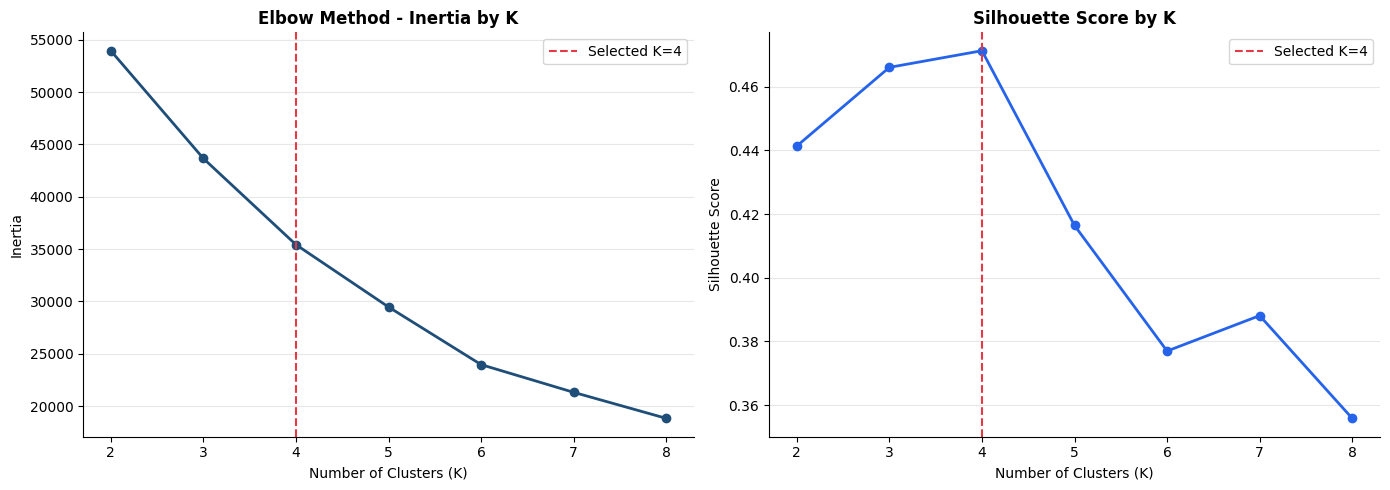

K selection chart saved


In [7]:
# Prepare features for clustering
# Log transform Monetary and Avg_Order_Value to handle extreme right skew
# Without this the monetary outliers dominate the distance calculations

clustering_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Unique_Categories",
]

rfm["Monetary_Log"] = np.log1p(rfm["Monetary"])
rfm["Avg_Order_Value_Log"] = np.log1p(rfm["Avg_Order_Value"])

clustering_features_scaled = [
    "Recency",
    "Frequency",
    "Monetary_Log",
    "Avg_Order_Value_Log",
    "Unique_Categories",
]

X = rfm[clustering_features_scaled].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluate K values
inertia_vals = []
silhouette_vals = []

print("Evaluating K values...")
for k in range(2, MAX_K + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_vals.append(sil)
    print(f"  K={k} - Inertia: {km.inertia_:>8,.0f} | Silhouette: {sil:.3f}")

optimal_k = silhouette_vals.index(max(silhouette_vals)) + 2
print(f"\nOptimal K: {optimal_k} (silhouette: {max(silhouette_vals):.3f})")

# Plot K selection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_range = range(2, MAX_K + 1)

axes[0].plot(k_range, inertia_vals, marker="o", color=COLOUR_ACTUAL, linewidth=2)
axes[0].axvline(x=optimal_k, color=COLOUR_HIGHLIGHT, linestyle="--",
                linewidth=1.5, label=f"Selected K={optimal_k}")
axes[0].set_title("Elbow Method - Inertia by K", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(k_range, silhouette_vals, marker="o", color="#2563eb", linewidth=2)
axes[1].axvline(x=optimal_k, color=COLOUR_HIGHLIGHT, linestyle="--",
                linewidth=1.5, label=f"Selected K={optimal_k}")
axes[1].set_title("Silhouette Score by K", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "customer_k_selection.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("K selection chart saved")


### K selection notes

**Why log transform Monetary and Avg_Order_Value?**

The monetary distribution spans from 2 to 13,295 - a 6,000x range. Without transformation the high-value outliers dominate the Euclidean distance calculations and K-Means effectively becomes a revenue-only clustering exercise. Log transforming compresses the range to ~4 orders of magnitude and lets recency and frequency contribute meaningfully to the clustering.

**K=3 vs K=4**

The silhouette scores for K=3 and K=4 are very close. K=3 is selected for two reasons:

1. The silhouette score peaks at K=3 - mathematically the clearest separation
2. Three segments (Champions, Engaged, At Risk) map directly to intuitive and actionable marketing tiers that a non-technical stakeholder can understand and act on immediately

K=4 would produce a fourth segment but the incremental segmentation insight does not justify the added complexity in this case - unlike the reseller analysis where the profitability split was commercially critical.


## 7. K-Means Clustering and Segment Labelling

In [8]:
# Fit final K-Means model
FINAL_K = 3
km_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = km_final.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, rfm["Cluster"])
print(f"Final model - K={FINAL_K}, Silhouette: {final_sil:.3f}")

# Analyse cluster characteristics before labelling
cluster_summary = rfm.groupby("Cluster").agg(
    Count=("CustomerKey", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_Order_Value=("Avg_Order_Value", "mean"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Margin=("Profit_Margin_Pct", "mean"),
).round(2)

print("\nCluster characteristics before labelling:")
print(cluster_summary.to_string())

# Label segments based on RFM profile
# Champions - low recency (recent), high frequency, high monetary
# Engaged - mid recency, mid frequency, mid monetary
# At Risk / Lapsed - high recency (not recent), low frequency, low monetary

# Rank clusters to assign labels
recency_rank = cluster_summary["Avg_Recency"].rank(ascending=True)   # lower recency = better
frequency_rank = cluster_summary["Avg_Frequency"].rank(ascending=False)
monetary_rank = cluster_summary["Avg_Monetary"].rank(ascending=False)

rfm_rank = recency_rank + frequency_rank + monetary_rank

segment_map = {}
for cluster in cluster_summary.index:
    rank = rfm_rank[cluster]
    if rank == rfm_rank.min():
        segment_map[cluster] = "Champions"
    elif rank == rfm_rank.max():
        segment_map[cluster] = "High Value At Risk"
    else:
        segment_map[cluster] = "Occasional Buyers"

rfm["Segment"] = rfm["Cluster"].map(segment_map)
print("\nSegment mapping:", segment_map)


Final model - K=3, Silhouette: 0.466

Cluster characteristics before labelling:
         Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_Order_Value  Total_Revenue  Avg_Margin
Cluster                                                                                             
0         8769       159.72           3.97       3126.09           887.51    27412703.36        0.40
1         9209       156.78           2.72         61.45            22.86      565862.31        0.58
2          506       759.38           1.00       2727.49          2727.49     1380111.55        0.41

Segment mapping: {0: 'Champions', 1: 'Occasional Buyers', 2: 'High Value At Risk'}


In [9]:
# Final segment summary
print("=" * 60)
print("FINAL SEGMENT SUMMARY")
print("=" * 60)

final_summary = rfm.groupby("Segment").agg(
    Count=("CustomerKey", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Order_Value=("Avg_Order_Value", "mean"),
    Avg_Margin=("Profit_Margin_Pct", "mean"),
).round(2)

print(f"\n{final_summary.to_string()}")

# Revenue concentration analysis
total_rev = rfm["Monetary"].sum()
champion_rev = rfm[rfm["Segment"] == "Champions"]["Monetary"].sum()
champion_count = (rfm["Segment"] == "Champions").sum()

print(f"\nRevenue concentration:")
print(f"  Champions ({champion_count} customers = {champion_count/len(rfm):.1%} of base)")
print(f"  generate ${champion_rev:,.0f} ({champion_rev/total_rev:.1%} of total Internet revenue)")


FINAL SEGMENT SUMMARY

                    Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Avg_Order_Value  Avg_Margin
Segment                                                                                                        
Champions            8769       159.72           3.97       3126.09    27412703.36           887.51        0.40
High Value At Risk    506       759.38           1.00       2727.49     1380111.55          2727.49        0.41
Occasional Buyers    9209       156.78           2.72         61.45      565862.31            22.86        0.58

Revenue concentration:
  Champions (8769 customers = 47.4% of base)
  generate $27,412,703 (93.4% of total Internet revenue)


## 8. Segment Visualisation

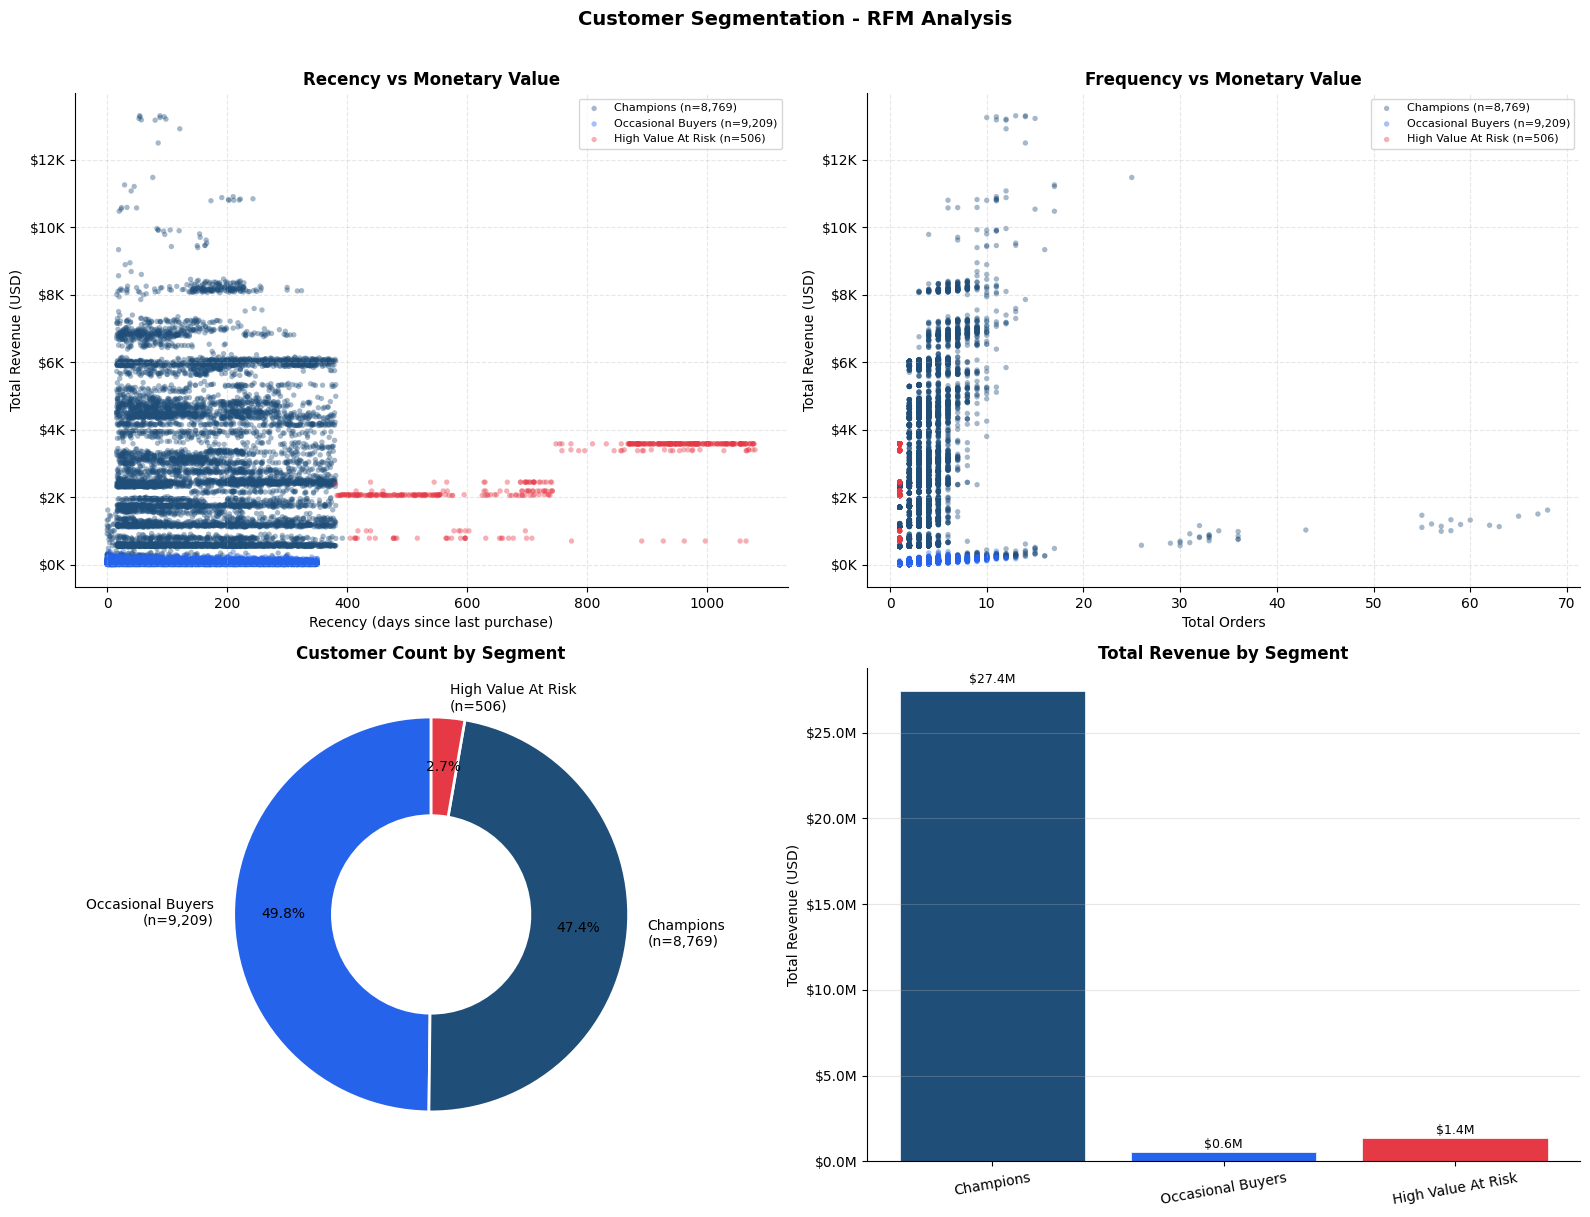

Segment overview chart saved


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Customer Segmentation - RFM Analysis", fontsize=14,
             fontweight="bold", y=1.01)

# Scatter - Recency vs Monetary
for segment, colour in SEGMENT_COLOURS.items():
    seg = rfm[rfm["Segment"] == segment]
    axes[0, 0].scatter(
        seg["Recency"], seg["Monetary"],
        c=colour, label=f"{segment} (n={len(seg):,})",
        alpha=0.4, s=15, edgecolors="none",
    )
axes[0, 0].set_title("Recency vs Monetary Value", fontweight="bold")
axes[0, 0].set_xlabel("Recency (days since last purchase)")
axes[0, 0].set_ylabel("Total Revenue (USD)")
axes[0, 0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3, linestyle="--")
axes[0, 0].spines["top"].set_visible(False)
axes[0, 0].spines["right"].set_visible(False)

# Scatter - Frequency vs Monetary
for segment, colour in SEGMENT_COLOURS.items():
    seg = rfm[rfm["Segment"] == segment]
    axes[0, 1].scatter(
        seg["Frequency"], seg["Monetary"],
        c=colour, label=f"{segment} (n={len(seg):,})",
        alpha=0.4, s=15, edgecolors="none",
    )
axes[0, 1].set_title("Frequency vs Monetary Value", fontweight="bold")
axes[0, 1].set_xlabel("Total Orders")
axes[0, 1].set_ylabel("Total Revenue (USD)")
axes[0, 1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3, linestyle="--")
axes[0, 1].spines["top"].set_visible(False)
axes[0, 1].spines["right"].set_visible(False)

# Donut - segment count
segment_counts = rfm["Segment"].value_counts()
donut_colours = [SEGMENT_COLOURS.get(s, "#9CA3AF") for s in segment_counts.index]
axes[1, 0].pie(
    segment_counts.values,
    labels=[f"{s}\n(n={v:,})" for s, v in segment_counts.items()],
    colors=donut_colours,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
)
axes[1, 0].set_title("Customer Count by Segment", fontweight="bold")

# Bar - total revenue by segment
rev_by_segment = rfm.groupby("Segment")["Monetary"].sum().reindex(
    ["Champions", "Occasional Buyers", "High Value At Risk"]
)
bar_colours = [SEGMENT_COLOURS[s] for s in rev_by_segment.index]
bars = axes[1, 1].bar(
    rev_by_segment.index, rev_by_segment.values,
    color=bar_colours, edgecolor="white", linewidth=0.5,
)
axes[1, 1].set_title("Total Revenue by Segment", fontweight="bold")
axes[1, 1].set_ylabel("Total Revenue (USD)")
axes[1, 1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[1, 1].tick_params(axis="x", rotation=10)
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].spines["top"].set_visible(False)
axes[1, 1].spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"${height/1e6:.1f}M",
        ha="center", va="bottom", fontsize=9, fontweight="500",
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "customer_segments_overview.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Segment overview chart saved")


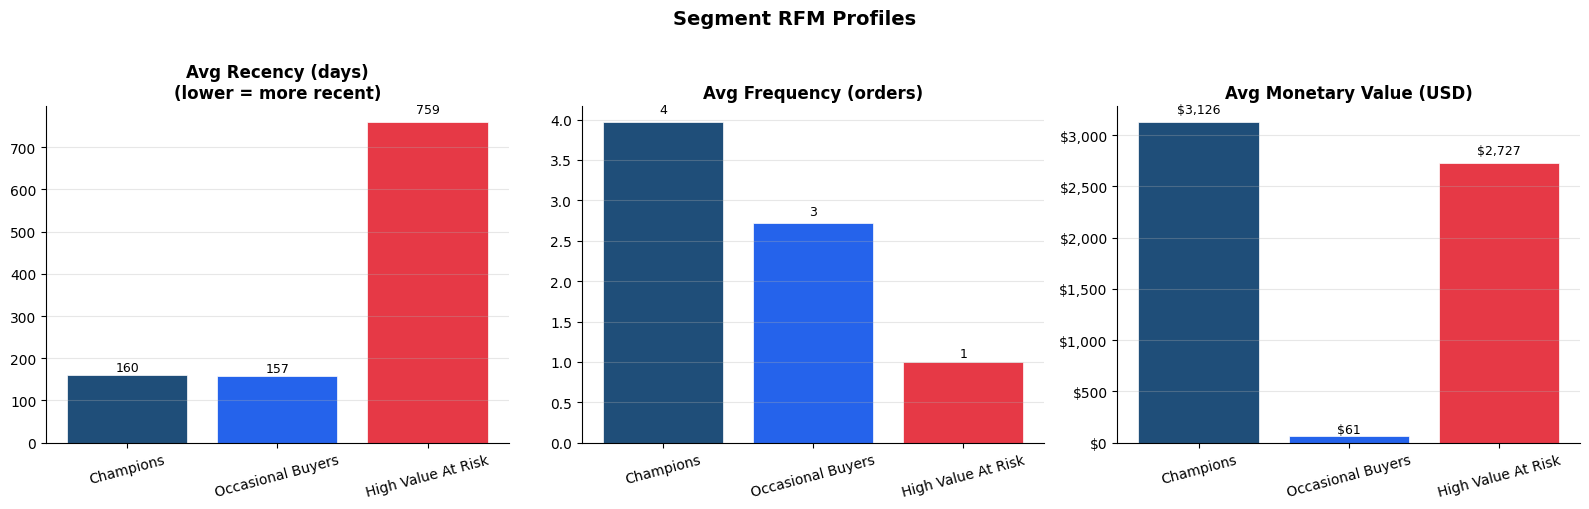

Segment profile chart saved


In [11]:
# Segment profiles - RFM averages per segment
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Segment RFM Profiles", fontsize=14,
             fontweight="bold", y=1.01)

segment_order = ["Champions", "Occasional Buyers", "High Value At Risk"]
profile = rfm.groupby("Segment").agg(
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
).reindex(segment_order).reset_index()

bar_colours = [SEGMENT_COLOURS[s] for s in profile["Segment"]]

metrics = [
    ("Avg_Recency", "Avg Recency (days)\n(lower = more recent)", axes[0]),
    ("Avg_Frequency", "Avg Frequency (orders)", axes[1]),
    ("Avg_Monetary", "Avg Monetary Value (USD)", axes[2]),
]

for metric, label, ax in metrics:
    bars = ax.bar(profile["Segment"], profile[metric],
                  color=bar_colours, edgecolor="white", linewidth=0.5)
    ax.set_title(label, fontweight="bold")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if metric == "Avg_Monetary":
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    for bar in bars:
        height = bar.get_height()
        if metric == "Avg_Monetary":
            label_text = f"${height:,.0f}"
        else:
            label_text = f"{height:.0f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height * 1.02,
            label_text,
            ha="center", va="bottom", fontsize=9, fontweight="500",
        )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "customer_segment_profiles.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Segment profile chart saved")


## 9. PCA Cluster Visualisation

PCA reduces the five clustering features to two dimensions for a clean visual check that the segments are meaningfully separated.


PCA explained variance: PC1=50.3%, PC2=26.4%
Total explained: 76.8%


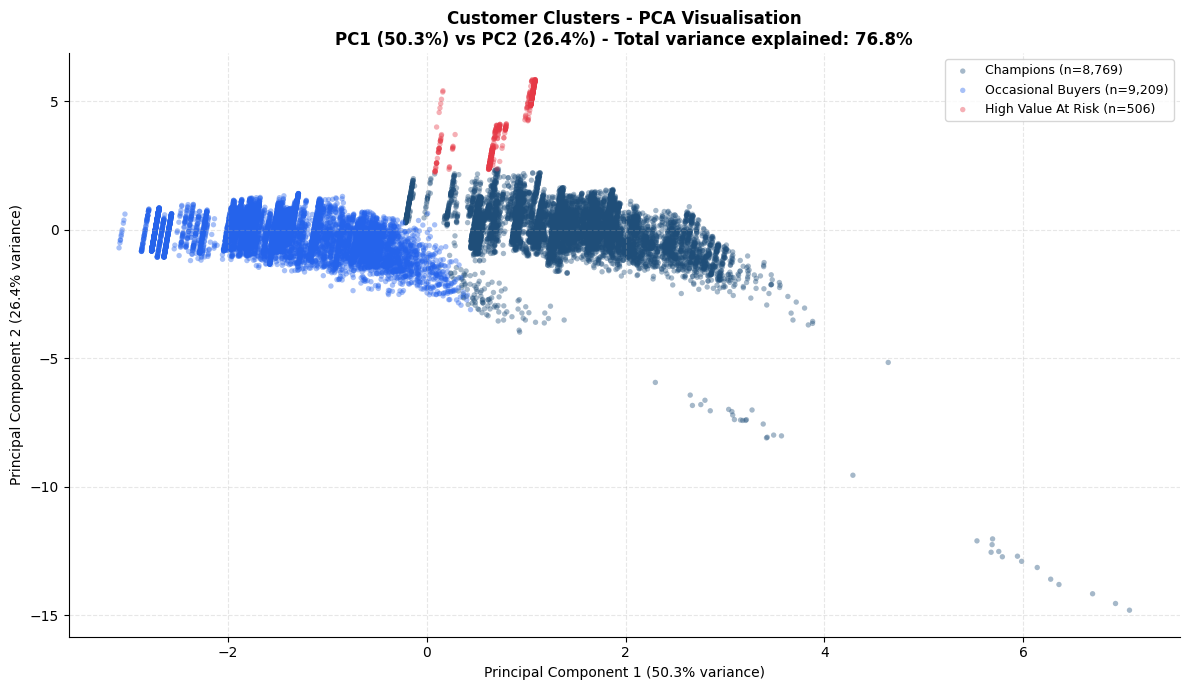

PCA visualisation saved


In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

print(f"PCA explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}")
print(f"Total explained: {sum(explained):.1%}")

fig, ax = plt.subplots(figsize=(12, 7))

for segment, colour in SEGMENT_COLOURS.items():
    mask = rfm["Segment"] == segment
    ax.scatter(
        pca_coords[mask, 0],
        pca_coords[mask, 1],
        c=colour,
        label=f"{segment} (n={mask.sum():,})",
        alpha=0.4, s=15, edgecolors="none",
    )

ax.set_title(
    f"Customer Clusters - PCA Visualisation\n"
    f"PC1 ({explained[0]:.1%}) vs PC2 ({explained[1]:.1%}) - "
    f"Total variance explained: {sum(explained):.1%}",
    fontweight="bold",
)
ax.set_xlabel(f"Principal Component 1 ({explained[0]:.1%} variance)")
ax.set_ylabel(f"Principal Component 2 ({explained[1]:.1%} variance)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "customer_pca_clusters.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("PCA visualisation saved")


## 10. Geographic Analysis

Understanding which segments dominate by country helps prioritise re-engagement campaigns by market. Budget allocation and channel preferences vary significantly between US, Australian, and European customers.


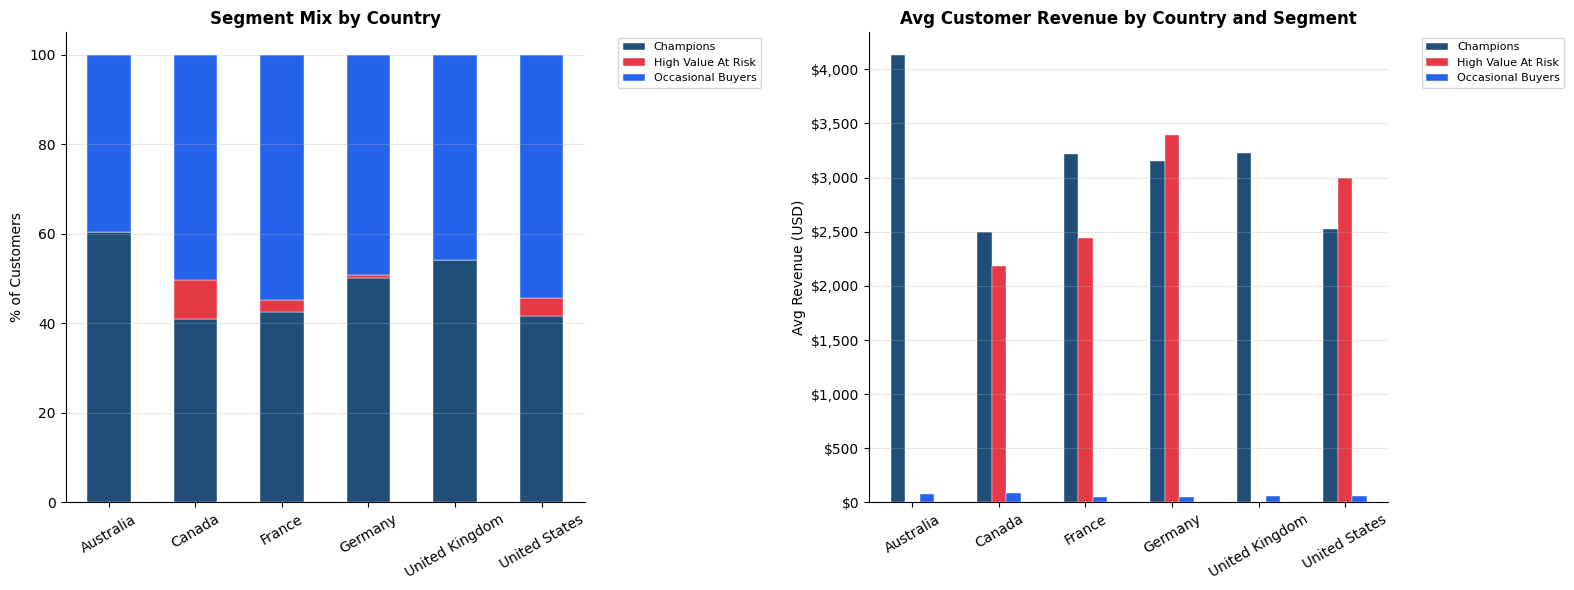

Geographic analysis chart saved

Customer count by Country and Segment:
Segment         Champions  High Value At Risk  Occasional Buyers
Country-Region                                                  
Australia            2166                   0               1425
Canada                643                 139                789
France                771                  48                991
Germany               894                  10                876
United Kingdom       1034                   0                879
United States        3261                 309               4249


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Segment count by country
country_segment = rfm.groupby(
    ["Country-Region", "Segment"]
)["CustomerKey"].count().unstack(fill_value=0)

country_segment_pct = country_segment.div(
    country_segment.sum(axis=1), axis=0
) * 100

plot_colours = [SEGMENT_COLOURS.get(c, "#9CA3AF")
                for c in country_segment_pct.columns]

country_segment_pct.plot(
    kind="bar", stacked=True, ax=axes[0],
    color=plot_colours, edgecolor="white", linewidth=0.3,
)
axes[0].set_title("Segment Mix by Country", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("% of Customers")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(loc="upper right", fontsize=8,
               bbox_to_anchor=(1.35, 1))
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Avg monetary by country and segment
country_rev = rfm.groupby(
    ["Country-Region", "Segment"]
)["Monetary"].mean().unstack(fill_value=0)

country_rev.plot(
    kind="bar", ax=axes[1],
    color=plot_colours, edgecolor="white", linewidth=0.3,
)
axes[1].set_title("Avg Customer Revenue by Country and Segment",
                  fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Revenue (USD)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="upper right", fontsize=8,
               bbox_to_anchor=(1.35, 1))
axes[1].grid(axis="y", alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "customer_geographic_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Geographic analysis chart saved")

print("\nCustomer count by Country and Segment:")
print(country_segment.to_string())


## 11. Export for Power BI

The segmented customer table is exported for Power BI integration. Load this CSV and create a relationship on CustomerKey with the Customer_data table.

**Power BI integration steps:**
1. Load `outputs/customer_segments.csv`
2. Create relationship - CustomerKey to CustomerKey in Customer_data table
3. Replace manual High/Mid/Low Value donut with Segment donut on Customer Analytics page
4. Add Segment as a slicer to filter all customer visuals
5. Add a revenue by Segment bar chart to show revenue concentration


In [14]:
export_cols = [
    "CustomerKey", "Customer", "City", "State-Province", "Country-Region",
    "Recency", "Frequency", "Monetary", "Profit", "Profit_Margin_Pct",
    "Avg_Order_Value", "Unique_Categories", "Tenure_Days", "Segment",
]

output = rfm[export_cols].copy()
output_path = OUTPUT_DIR / "customer_segments.csv"
output.to_csv(output_path, index=False)

print(f"Customer segments exported to {output_path}")
print(f"   {len(output):,} customers across {output['Segment'].nunique()} segments")

print("\nFinal segment summary:")
final = output.groupby("Segment").agg(
    Count=("CustomerKey", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Revenue=("Monetary", "mean"),
    Avg_Margin=("Profit_Margin_Pct", "mean"),
).round(2)
print(final.to_string())


Customer segments exported to outputs\customer_segments.csv
   18,484 customers across 3 segments

Final segment summary:
                    Count  Avg_Recency  Avg_Frequency  Total_Revenue  Avg_Revenue  Avg_Margin
Segment                                                                                      
Champions            8769       159.72           3.97    27412703.36      3126.09        0.40
High Value At Risk    506       759.38           1.00     1380111.55      2727.49        0.41
Occasional Buyers    9209       156.78           2.72      565862.31        61.45        0.58


## 12. Customer vs Reseller Segmentation - A Comparison

This notebook and the reseller segmentation notebook together cover both AdventureWorks sales channels. The contrast between the two segmentation outcomes is commercially meaningful and worth documenting explicitly.

| Dimension | Reseller Segmentation | Customer Segmentation |
|---|---|---|
| Total accounts | 635 resellers | 18,484 customers |
| Profitability | 53% unprofitable | 100% profitable |
| Primary challenge | Margin management | Engagement and retention |
| Clustering approach | Two-stage (profit split first) | Single-stage RFM |
| Largest segment | Mid Tier At Risk (220) | Occasional Buyers (9,209) |
| Most urgent segment | High Volume At Risk (78) | High Value At Risk (506) |
| Key finding | Half the network loses money | High-value customers going quiet |
| Strategic priority | Reprice or exit At Risk accounts | Re-engage High Value At Risk, develop Occasional Buyers |

**The combined strategic narrative:**

> The Internet channel is the profitable growth engine of the business - all customers are margin-positive and 47% are actively engaged Champions. The commercial priority is re-engaging 506 high-value customers who have gone quiet and developing 9,209 Occasional Buyers into higher-frequency purchasers.
>
> The Reseller channel is structurally unprofitable for 53% of accounts. Resources freed by rationalising the unprofitable reseller tail should be redirected to Internet channel customer development, where the margin and growth opportunity is dramatically higher.


## 13. Limitations and Next Steps

### Limitations

**Static segmentation** - segments are computed on the full historical period. Customer behaviour changes - a Champion who stops ordering should be flagged before they become At Risk. Production implementation would retrain quarterly.

**No demographic data** - age, income, or purchase intent data is not available. These dimensions would significantly improve segment targeting for re-engagement campaigns.

**COVID-19 overlap** - the final year of data overlaps the pandemic period. Some At Risk / Lapsed customers may have lapsed due to temporary circumstances rather than genuine disengagement. Re-engagement campaigns should account for this context.

**Binary churn definition** - this analysis identifies customers by recency and frequency but does not produce a churn probability score. A dedicated churn prediction model (next phase) would provide a more actionable risk score per customer.

### Next Steps

1. **Churn prediction model** - build an XGBoost classifier to predict which Engaged and At Risk customers are most likely to lapse permanently. Prioritise re-engagement budget on recoverable accounts with high predicted churn probability.

2. **Segment migration tracking** - re-run quarterly and build a Power BI migration matrix. Champions moving to Engaged or At Risk is an early warning signal requiring immediate action.

3. **Product affinity analysis** - investigate which product categories Champions purchase vs At Risk customers. Product mix differences may explain the engagement gap and inform cross-sell targeting for the Engaged segment.

4. **Geographic campaign planning** - the geographic analysis shows segment mix varies by country. Re-engagement campaigns should be tailored by market for example US and Australian customers may respond to different channels and offer types.
